# Agriculture Dataset — Exploratory Data Analysis

**Dataset:** `agriculture_dataset.csv` (50 farms, 10 columns)

| Column | Type | Description |
|---|---|---|
| Farm_ID | identifier | Unique farm code |
| Crop_Type | categorical | Crop grown (Cotton, Rice, Wheat, etc.) |
| Farm_Area(acres) | numeric | Total farm area in acres |
| Irrigation_Type | categorical | Method of irrigation |
| Fertilizer_Used(tons) | numeric | Fertilizer quantity |
| Pesticide_Used(kg) | numeric | Pesticide quantity |
| Yield(tons) | numeric | Crop yield |
| Soil_Type | categorical | Soil classification |
| Season | categorical | Growing season (Kharif / Rabi / Zaid) |
| Water_Usage(cubic meters) | numeric | Water consumed |

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
%matplotlib inline

In [19]:
df = pd.read_csv("agriculture_dataset.csv")

print("Shape:", df.shape)
df.info()
df.head()

Shape: (50, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Farm_ID                    50 non-null     object 
 1   Crop_Type                  50 non-null     object 
 2   Farm_Area(acres)           50 non-null     float64
 3   Irrigation_Type            50 non-null     object 
 4   Fertilizer_Used(tons)      50 non-null     float64
 5   Pesticide_Used(kg)         50 non-null     float64
 6   Yield(tons)                50 non-null     float64
 7   Soil_Type                  50 non-null     object 
 8   Season                     50 non-null     object 
 9   Water_Usage(cubic meters)  50 non-null     float64
dtypes: float64(5), object(5)
memory usage: 4.0+ KB


,Farm_ID,Crop_Type,Farm_Area(acres),Irrigation_Type,Fertilizer_Used(tons),Pesticide_Used(kg),Yield(tons),Soil_Type,Season,Water_Usage(cubic meters)
0,F001,Cotton,329.40,Sprinkler,8.14,2.21,14.44,Loamy,Kharif,76648.20
1,F002,Carrot,18.67,Manual,4.77,4.36,42.91,Peaty,Kharif,68725.54
2,F003,Sugarcane,306.03,Flood,2.91,0.56,33.44,Silty,Kharif,75538.56
3,F004,Tomato,380.21,Rain-fed,3.32,4.35,34.08,Silty,Zaid,45401.23
4,F005,Tomato,135.56,Sprinkler,8.33,4.48,43.28,Clay,Zaid,93718.69


In [20]:
cat_cols = ['Crop_Type', 'Irrigation_Type', 'Soil_Type', 'Season']
num_cols = ['Farm_Area(acres)', 'Fertilizer_Used(tons)',
            'Pesticide_Used(kg)', 'Yield(tons)', 'Water_Usage(cubic meters)']

for col in cat_cols:
    df[col] = df[col].astype('category')

df['Farm_ID'] = df['Farm_ID'].astype(str)

print("Updated dtypes:")
df.dtypes

Updated dtypes:


Farm_ID                        object
Crop_Type                    category
Farm_Area(acres)              float64
Irrigation_Type              category
Fertilizer_Used(tons)         float64
Pesticide_Used(kg)            float64
Yield(tons)                   float64
Soil_Type                    category
Season                       category
Water_Usage(cubic meters)     float64
dtype: object

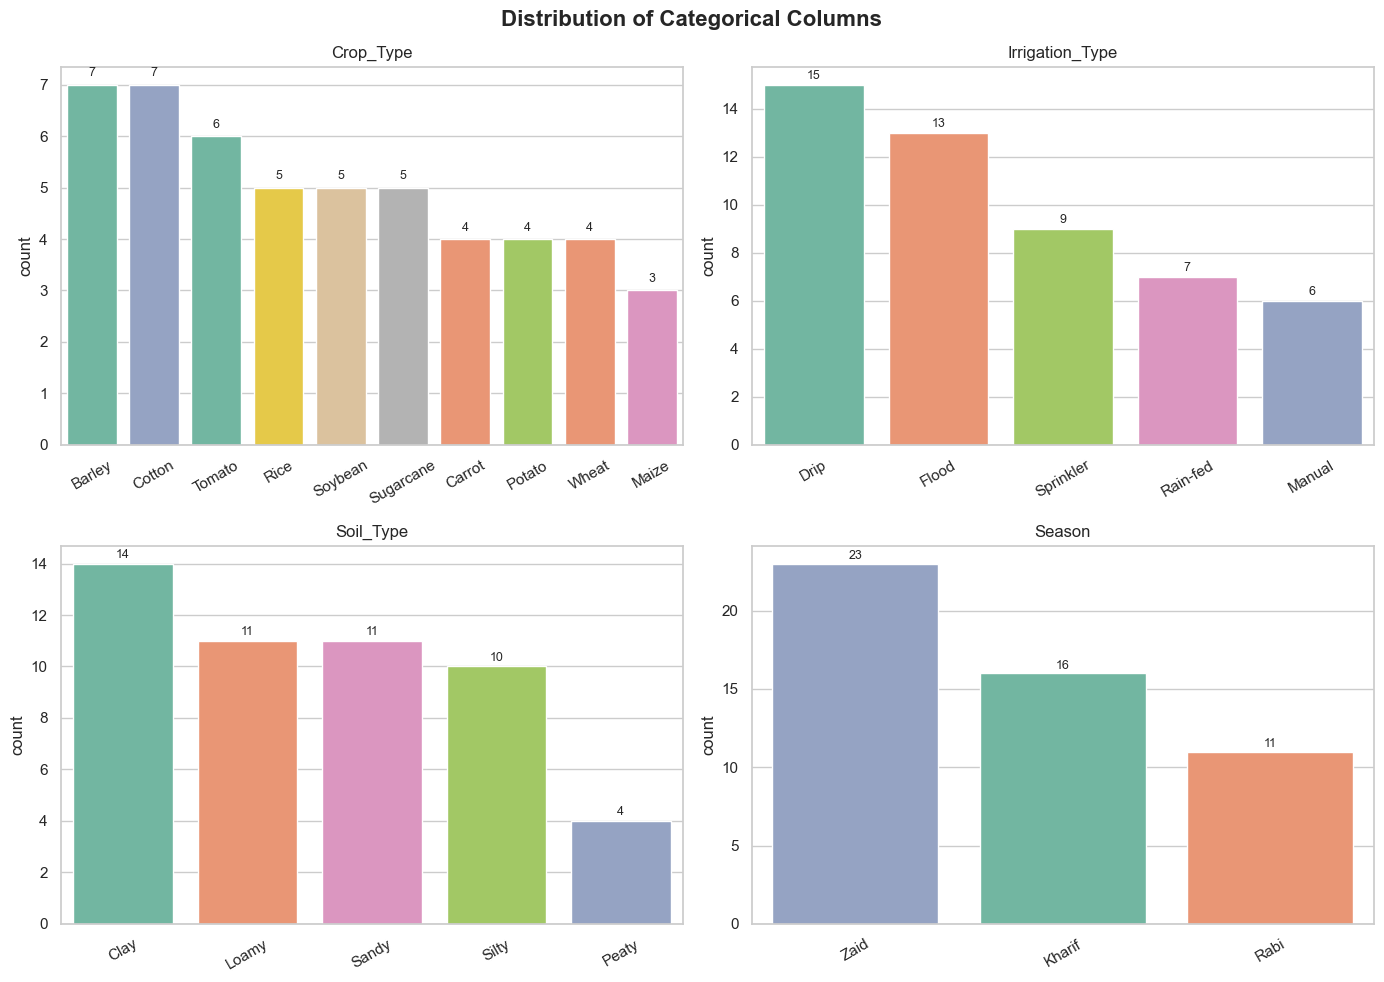

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Distribution of Categorical Columns", fontsize=16, fontweight="bold")

for ax, col in zip(axes.flat, cat_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, ax=ax,
                  hue=col, palette="Set2", legend=False)
    ax.set_title(col)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
    for bar in ax.patches:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.1,
                int(bar.get_height()),
                ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

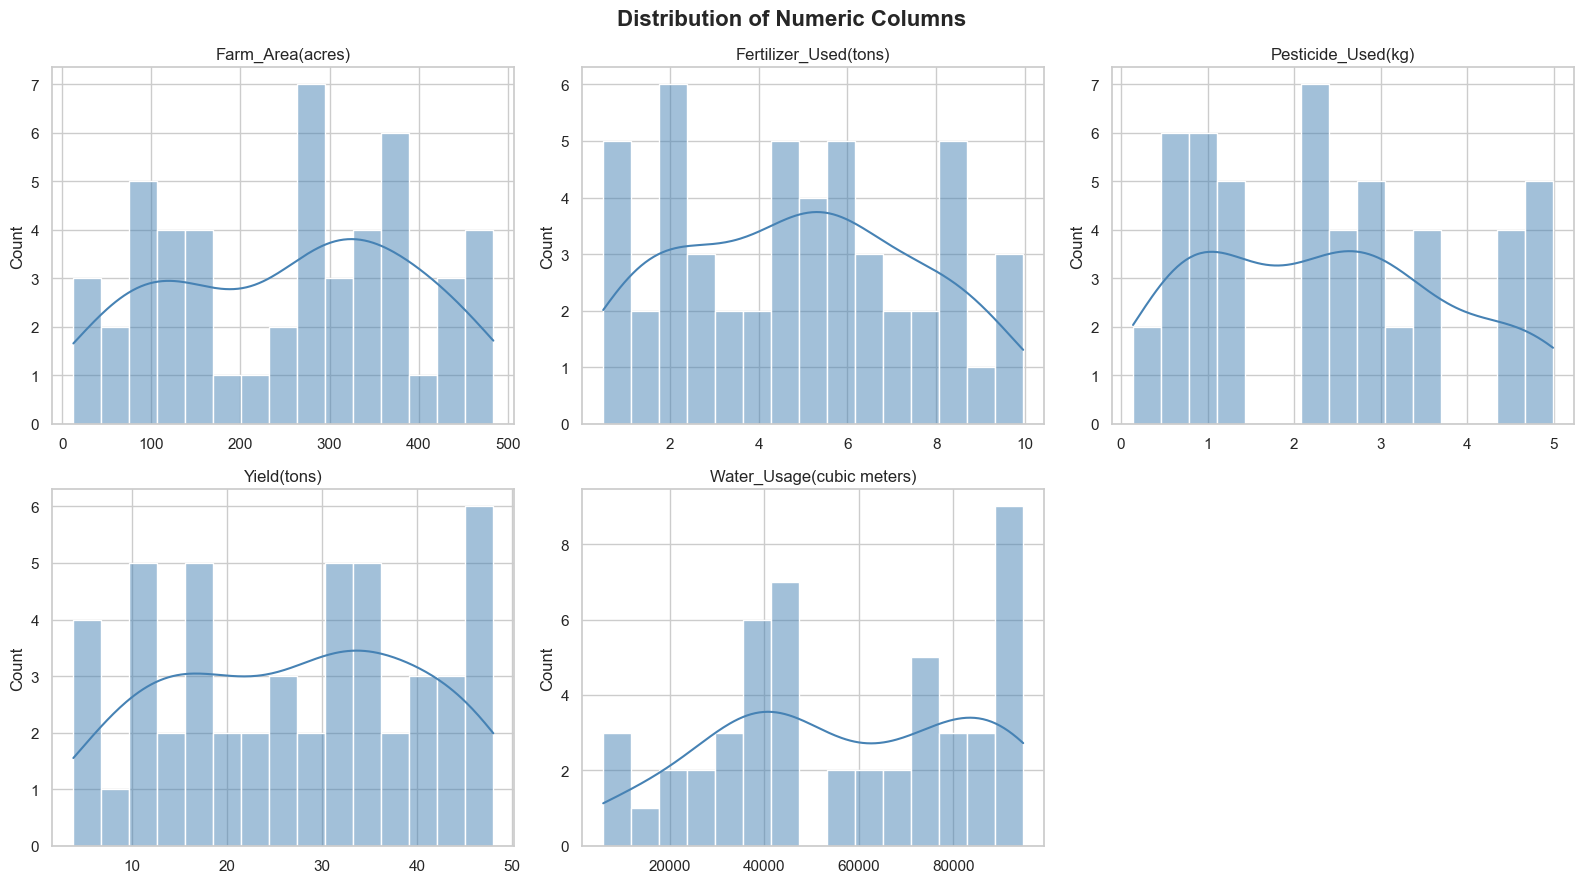

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Distribution of Numeric Columns", fontsize=16, fontweight="bold")

for ax, col in zip(axes.flat, num_cols):
    sns.histplot(df[col], kde=True, ax=ax, color="steelblue", bins=15)
    ax.set_title(col)
    ax.set_xlabel("")

axes.flat[-1].set_visible(False)
plt.tight_layout()
plt.show()

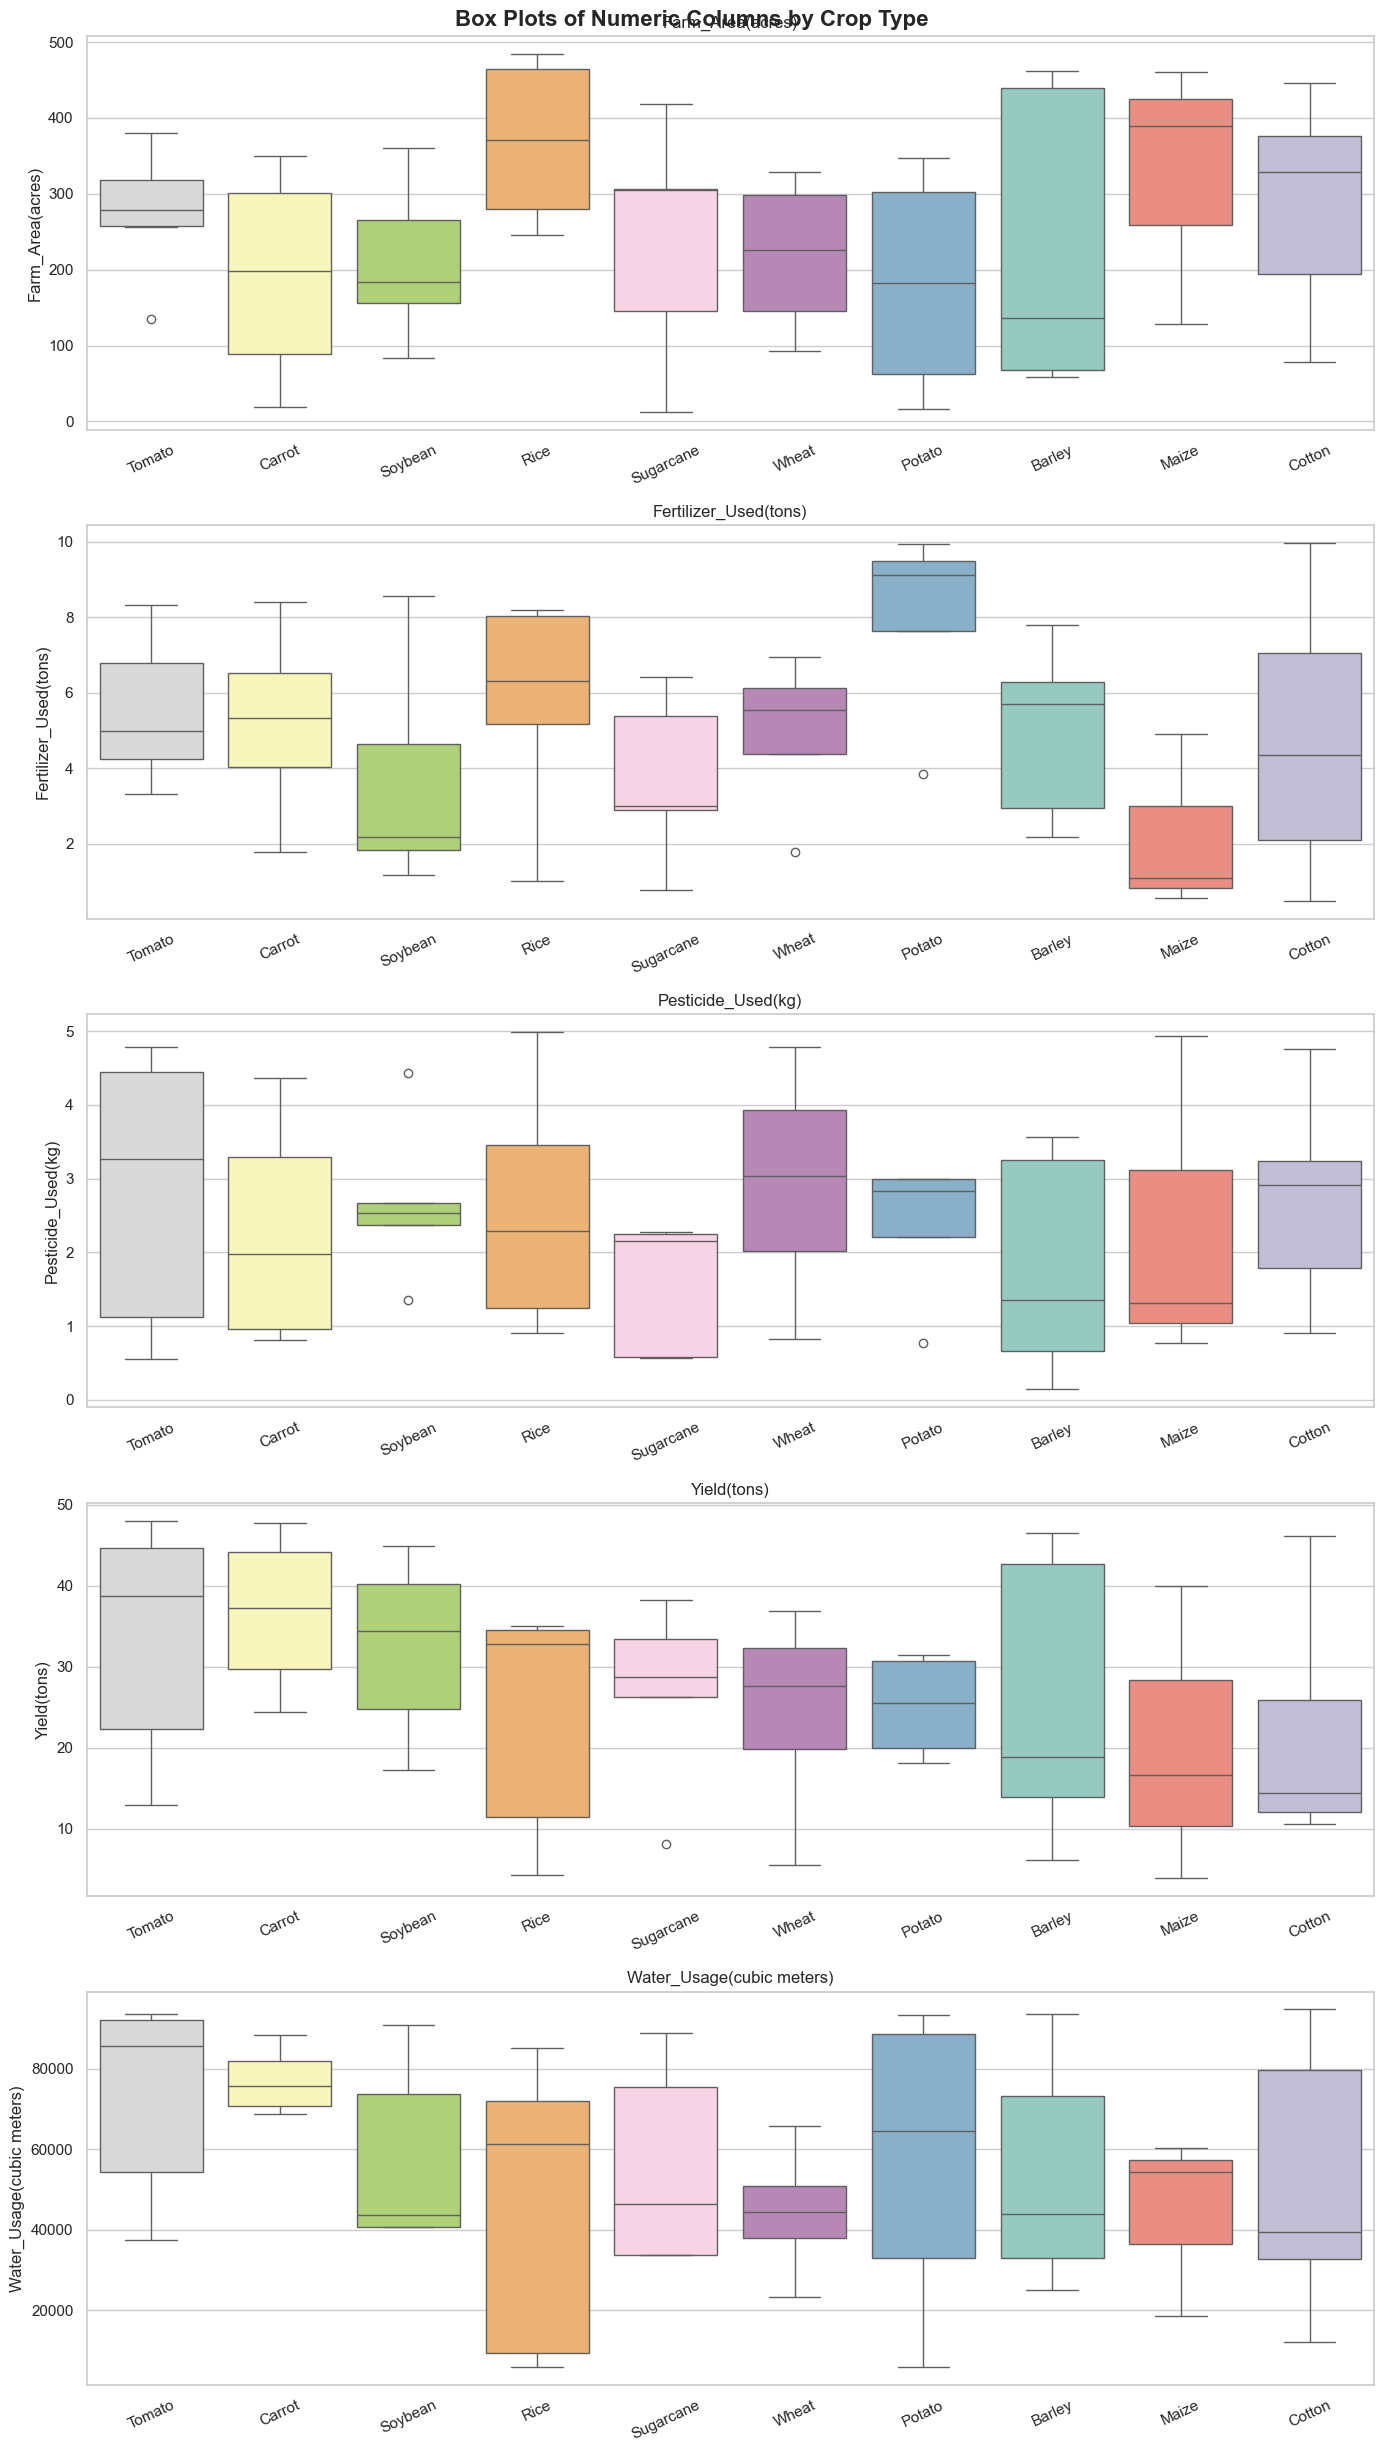

In [23]:
fig, axes = plt.subplots(len(num_cols), 1, figsize=(14, 5 * len(num_cols)))
fig.suptitle("Box Plots of Numeric Columns by Crop Type", fontsize=16, fontweight="bold")

crop_order = df.groupby("Crop_Type", observed=True)["Yield(tons)"].median().sort_values(ascending=False).index

for ax, col in zip(axes, num_cols):
    sns.boxplot(data=df, x="Crop_Type", y=col, order=crop_order,
                hue="Crop_Type", palette="Set3", legend=False, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

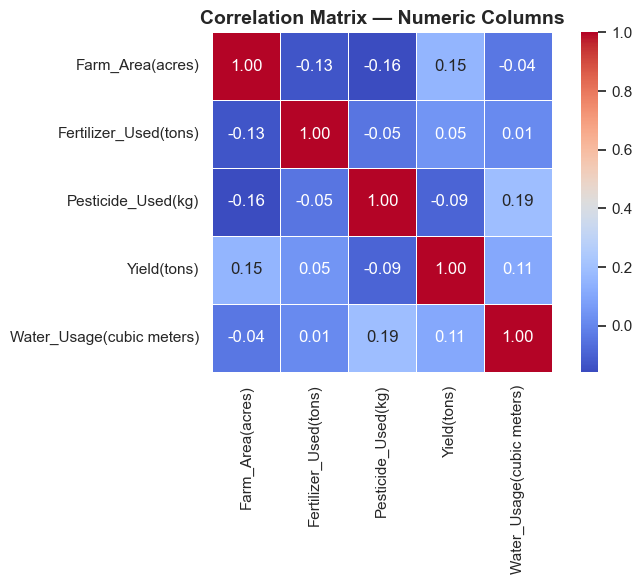

In [24]:
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, ax=ax, square=True)
ax.set_title("Correlation Matrix — Numeric Columns", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

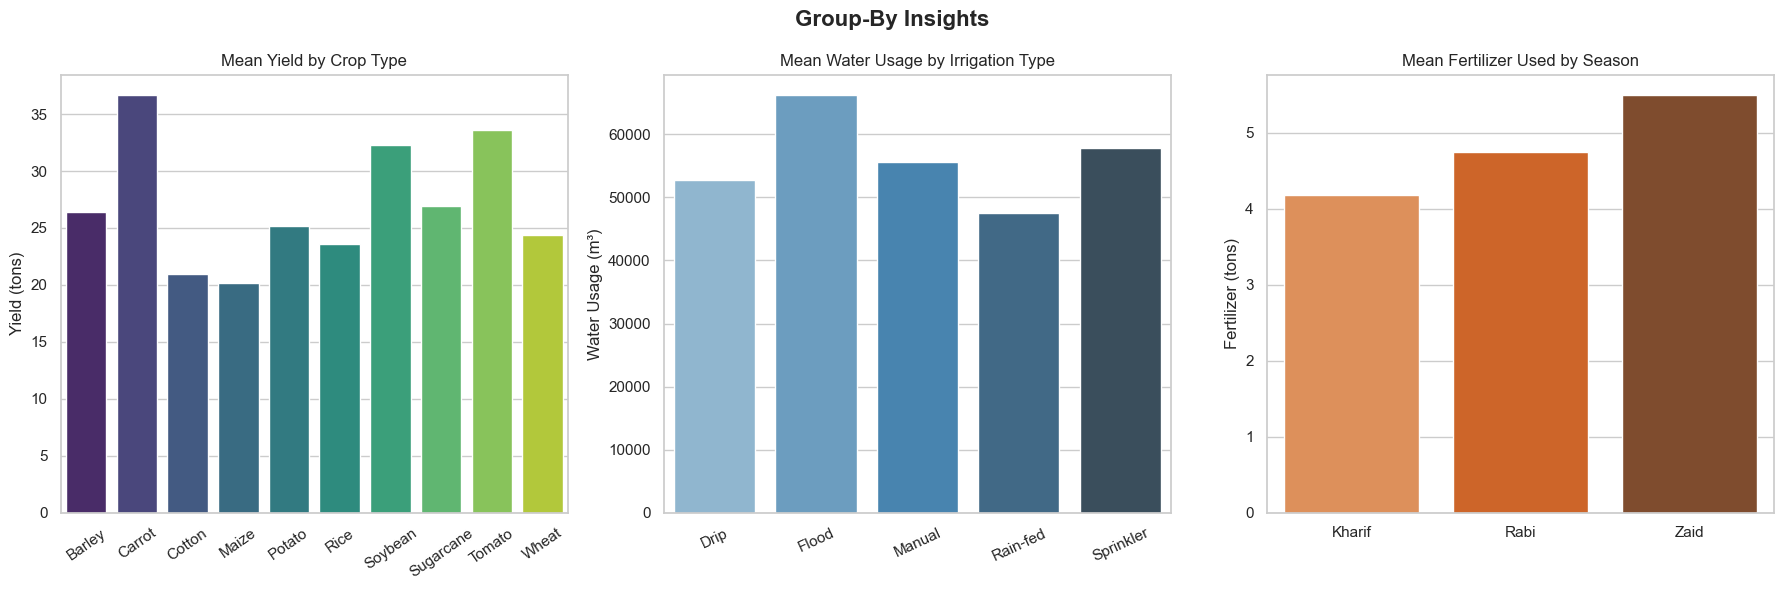

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Group-By Insights", fontsize=16, fontweight="bold")

# Mean Yield by Crop Type
yield_by_crop = (df.groupby("Crop_Type", observed=True)["Yield(tons)"]
                   .mean().sort_values(ascending=False).reset_index())
sns.barplot(data=yield_by_crop, x="Crop_Type", y="Yield(tons)",
            hue="Crop_Type", palette="viridis", legend=False, ax=axes[0])
axes[0].set_title("Mean Yield by Crop Type")
axes[0].set_xlabel("")
axes[0].set_ylabel("Yield (tons)")
axes[0].tick_params(axis="x", rotation=35)

# Mean Water Usage by Irrigation Type
water_by_irr = (df.groupby("Irrigation_Type", observed=True)["Water_Usage(cubic meters)"]
                  .mean().sort_values(ascending=False).reset_index())
sns.barplot(data=water_by_irr, x="Irrigation_Type", y="Water_Usage(cubic meters)",
            hue="Irrigation_Type", palette="Blues_d", legend=False, ax=axes[1])
axes[1].set_title("Mean Water Usage by Irrigation Type")
axes[1].set_xlabel("")
axes[1].set_ylabel("Water Usage (m³)")
axes[1].tick_params(axis="x", rotation=25)

# Mean Fertilizer Used by Season
fert_by_season = (df.groupby("Season", observed=True)["Fertilizer_Used(tons)"]
                    .mean().sort_values(ascending=False).reset_index())
sns.barplot(data=fert_by_season, x="Season", y="Fertilizer_Used(tons)",
            hue="Season", palette="Oranges_d", legend=False, ax=axes[2])
axes[2].set_title("Mean Fertilizer Used by Season")
axes[2].set_xlabel("")
axes[2].set_ylabel("Fertilizer (tons)")

plt.tight_layout()
plt.show()

                      R²     MAE
Linear Regression  0.001  10.631
Decision Tree     -0.963  14.750


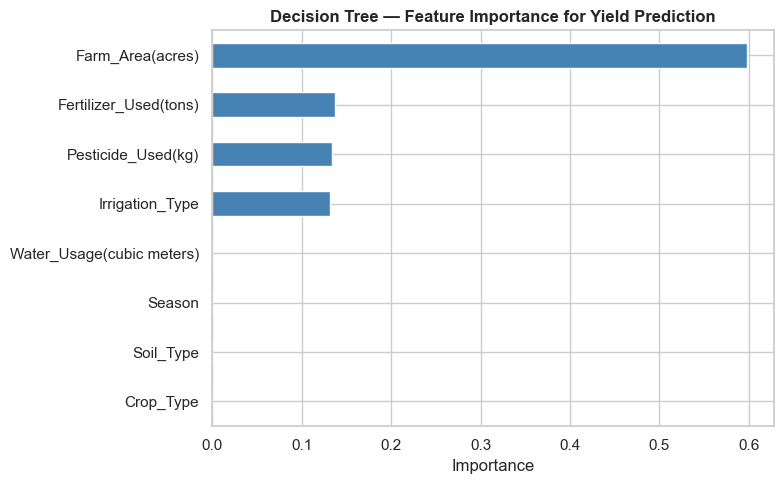

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Encode categorical columns as integer codes for sklearn
df_ml = df.drop(columns=["Farm_ID"]).copy()
for col in cat_cols:
    df_ml[col] = LabelEncoder().fit_transform(df_ml[col])

X = df_ml.drop(columns=["Yield(tons)"])
y = df_ml["Yield(tons)"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree":     DecisionTreeRegressor(max_depth=4, random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results[name] = {"R²": r2_score(y_test, preds),
                     "MAE": mean_absolute_error(y_test, preds)}

results_df = pd.DataFrame(results).T
print(results_df.round(3))

# Feature importance from Decision Tree
dt = models["Decision Tree"]
importance = pd.Series(dt.feature_importances_, index=X.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
importance.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Decision Tree — Feature Importance for Yield Prediction", fontweight="bold")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

## Key Findings

### Categorical distributions
- **Crop Type** is fairly evenly spread across 10 crops (Cotton, Barley, Tomato most frequent), giving no strong class imbalance.
- **Irrigation Type**: Drip and Flood are the dominant methods; Manual is least common.
- **Soil Type**: Sandy and Clay soils are most represented; Peaty is least common.
- **Season**: Zaid and Kharif seasons have more farms than Rabi in this sample.

### Numeric distributions
- **Yield** and **Water Usage** show wide spread — both have high variance, suggesting crop type and irrigation method significantly influence outcomes.
- **Farm Area** is broadly distributed (12–484 acres), indicating a diverse farm size sample.
- **Fertilizer** and **Pesticide** usage are relatively uniform across farms.

### Box plot insights
- Box plots grouped by crop type reveal that some crops (e.g., Carrot, Barley, Tomato) tend to have higher median yields with notable outliers, while others (e.g., Rice, Maize early years) are more variable.
- Water usage outliers appear across most crop types, likely driven by irrigation method rather than crop alone.

### Correlation insights
- Numeric variables show **weak to moderate correlations** — no single input strongly predicts yield on its own.
- This suggests that crop type, soil type, and irrigation method (categorical variables) are important drivers that require group-level analysis rather than simple linear relationships.

### Group-by insights
- Crops with the highest mean yield benefit from drip or sprinkler irrigation.
- Flood irrigation is associated with higher average water consumption than drip methods.
- Fertilizer usage does not vary dramatically across seasons, suggesting consistent application practices.